In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_3000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [3]:
n.generators.loc[['BA0 0 0 solar'], ['p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt', 'p_nom_extendable']]

,p_nom,p_nom_min,p_nom_max,p_nom_opt,p_nom_extendable
Generator,,,,,
BA0 0 0 solar,883.868019,574.514212,1193.221825,574.517672,True


In [4]:
path = Path.cwd().parent / 'results' / 'duals'
template = 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+{}_{}_{}_mu.csv'
fns = list(path.glob('*.csv'))

In [5]:
def weighted_average(quantity: pd.Series, weights: pd.Series) -> float:
    """
    Compute the weighted average of `quantity` using `weights`.

    Both inputs must be pandas Series with the same index.
    NaNs are dropped pairwise. Returns NaN if no valid data or sum of weights is 0.
    """
    if not isinstance(quantity, pd.Series) or not isinstance(weights, pd.Series):
        raise TypeError("quantity and weights must both be pandas Series.")

    if not quantity.index.equals(weights.index):
        raise ValueError("quantity and weights must have the same index (same labels and order).")

    df = pd.concat({"q": quantity, "w": weights}, axis=1).dropna()
    if df.empty:
        return float("nan")

    wsum = df["w"].sum()
    if wsum == 0:
        return float("nan")

    return (df["q"] * df["w"]).sum() / wsum

In [16]:
from tqdm import tqdm

uppers_fast = list()
lowers_fast = list()
uppers_medium = list()
lowers_medium = list()

carriers = [
    'offwind',
    'onwind',
    'solar',
    'industrial heat pump high temperature',
    'industrial heat pump medium temperature',
    'air heat pump',
    'ground heat pump',
    'CCGT',
    'OCGT',
    'biomass boiler',
]

wiggles = list(range(1000, 4250, 250))

# Process 'fast' scenario
for wiggle in tqdm(wiggles):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+{}_{}.nc'.format('fast', wiggle)
    )

    uppers_df = pd.read_csv(
            path / template.format('fast', wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    
    # print(uppers_df.index.isin(n.generators.index.union(n.links.index)).all())

    index = list()
    weighted_avg = list()
    avg = list()

    for carrier in carriers:

        ss = uppers_df.loc[uppers_df.index.str.contains(carrier)]

        if ss.empty:
            continue

        gens = ss.index[ss.index.str.contains(carrier)].intersection(n.generators.index)
        links = ss.index[ss.index.str.contains(carrier)].intersection(n.links.index)

        caps = n.generators.loc[gens, 'p_nom_opt'] if links.empty else n.links.loc[links, 'p_nom_opt']

        wgt_avg = weighted_average(ss, caps)

        # print(carrier)
        # print(wgt_avg)
        # print(ss.mean())

        index.append(carrier)
        weighted_avg.append(wgt_avg)
        avg.append(ss.mean())
    
    uppers_fast.append(
        pd.DataFrame(
            {'weighted_avg': weighted_avg, 'avg': avg},
            index=index
        )
    )

# Process 'medium' scenario
for wiggle in tqdm(wiggles):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+{}_{}.nc'.format('medium', wiggle)
    )

    uppers_df = pd.read_csv(
            path / template.format('medium', wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    
    # print(uppers_df.index.isin(n.generators.index.union(n.links.index)).all())

    index = list()
    weighted_avg = list()
    avg = list()

    for carrier in carriers:

        ss = uppers_df.loc[uppers_df.index.str.contains(carrier)]

        if ss.empty:
            continue

        gens = ss.index[ss.index.str.contains(carrier)].intersection(n.generators.index)
        links = ss.index[ss.index.str.contains(carrier)].intersection(n.links.index)

        caps = n.generators.loc[gens, 'p_nom_opt'] if links.empty else n.links.loc[links, 'p_nom_opt']

        wgt_avg = weighted_average(ss, caps)

        # print(carrier)
        # print(wgt_avg)
        # print(ss.mean())

        index.append(carrier)
        weighted_avg.append(wgt_avg)
        avg.append(ss.mean())
    
    uppers_medium.append(
        pd.DataFrame(
            {'weighted_avg': weighted_avg, 'avg': avg},
            index=index
        )
    )

100%|██████████| 13/13 [02:47<00:00, 12.90s/it]


In [17]:
uppers = pd.concat(uppers_fast, axis=1, keys=wiggles)
medium = pd.concat(uppers_medium, axis=1, keys=wiggles)

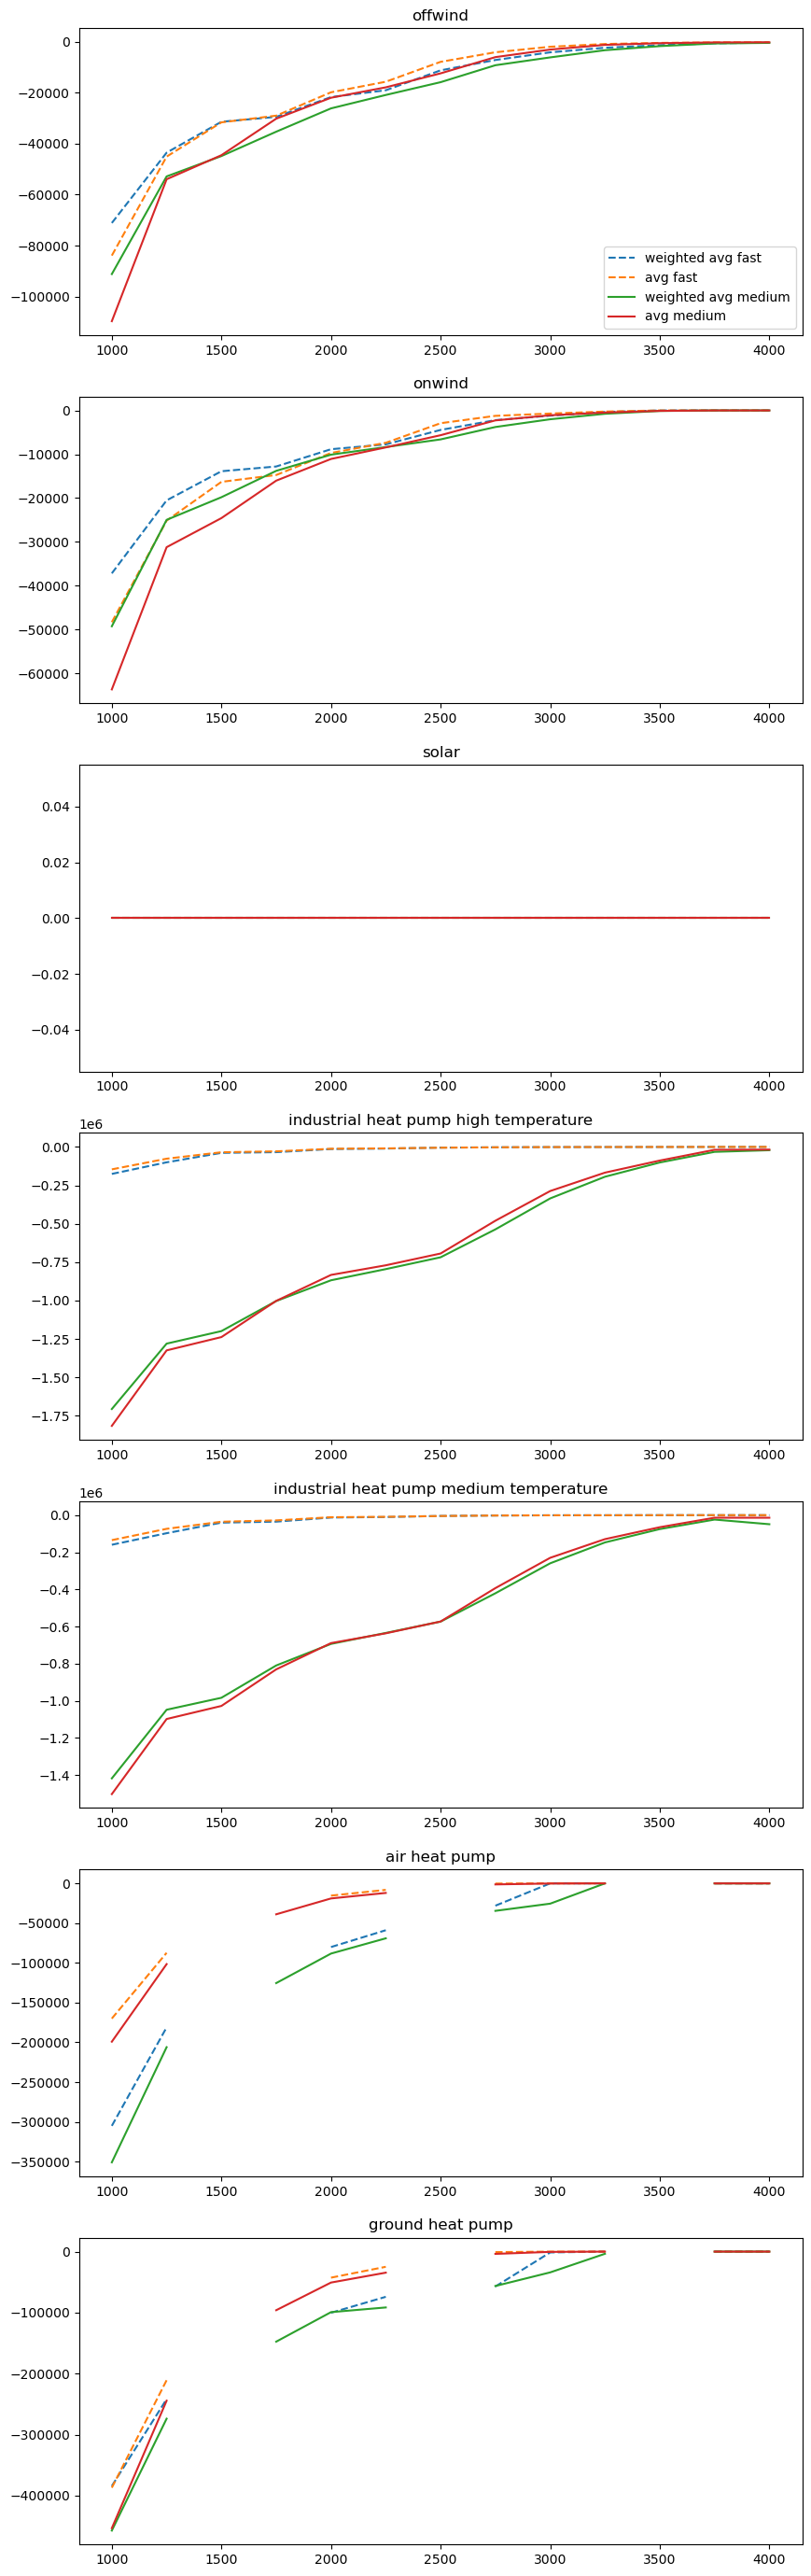

In [20]:
idx = pd.IndexSlice

fig, axs = plt.subplots(len(uppers.index), 1, figsize=(10, len(uppers.index) * 5))


for i, (carrier, ax) in enumerate(zip(uppers.index, axs)):
    
    ss = uppers.loc[carrier].unstack()

    ax.plot(ss.index, ss.loc[:, 'weighted_avg'], label='weighted avg fast', ls='--')
    ax.plot(ss.index, ss.loc[:, 'avg'], label='avg fast', ls='--')

    ss = medium.loc[carrier].unstack()

    ax.plot(ss.index, ss.loc[:, 'weighted_avg'], label='weighted avg medium', ls='-')
    ax.plot(ss.index, ss.loc[:, 'avg'], label='avg medium', ls='-')

    ax.set_title(carrier)

    if not i:
        ax.legend()

plt.show()

In [115]:
n.generators.loc[n.generators.index.str.contains('offwind')].capital_cost

Generator
AL0 0 0 offwind-float    295775.684948
BA0 0 0 offwind-float    289260.940080
BE0 0 0 offwind-float    293290.029022
BG0 0 0 offwind-float    297816.980591
DE0 0 0 offwind-float    295544.785594
                             ...      
NL0 0 0 offwind-dc       237284.163108
NO1 0 0 offwind-dc       236800.860740
PL0 0 0 offwind-dc       223961.928240
RO0 0 0 offwind-dc       222124.145120
SE1 0 0 offwind-dc       227113.643892
Name: capital_cost, Length: 101, dtype: float64

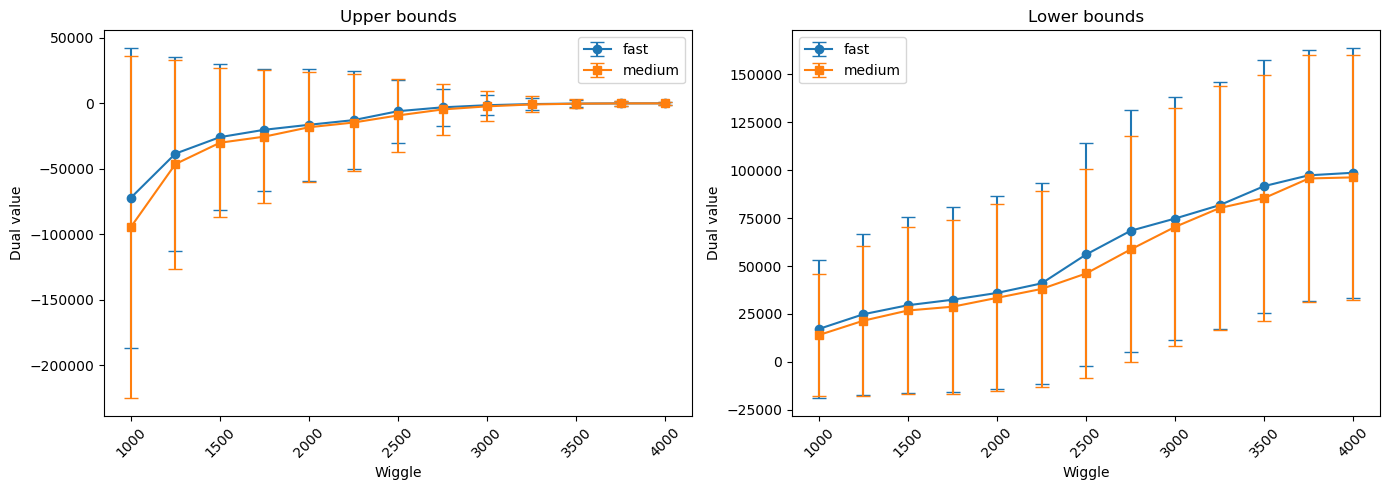

In [94]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

carrier = 'wind'

# Prepare data for upper bounds
ss_fast = uppers_fast.loc[uppers_fast.index.str.contains(carrier)]
ss_medium = uppers_medium.loc[uppers_medium.index.str.contains(carrier)]

# Calculate mean and std for upper bounds
mean_fast_upper = ss_fast.mean()
std_fast_upper = ss_fast.std()
mean_medium_upper = ss_medium.mean()
std_medium_upper = ss_medium.std()

# Plot upper bounds
axs[0].errorbar(mean_fast_upper.index, mean_fast_upper.values, yerr=std_fast_upper.values, 
                label='fast', marker='o', capsize=5)
axs[0].errorbar(mean_medium_upper.index, mean_medium_upper.values, yerr=std_medium_upper.values, 
                label='medium', marker='s', capsize=5)
axs[0].set_title('Upper bounds')
axs[0].set_xlabel('Wiggle')
axs[0].set_ylabel('Dual value')
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()

# Prepare data for lower bounds
ss_fast_lower = lowers_fast.loc[lowers_fast.index.str.contains(carrier)]
ss_medium_lower = lowers_medium.loc[lowers_medium.index.str.contains(carrier)]

# Calculate mean and std for lower bounds
mean_fast_lower = ss_fast_lower.mean()
std_fast_lower = ss_fast_lower.std()
mean_medium_lower = ss_medium_lower.mean()
std_medium_lower = ss_medium_lower.std()

# Plot lower bounds
axs[1].errorbar(mean_fast_lower.index, mean_fast_lower.values, yerr=std_fast_lower.values, 
                label='fast', marker='o', capsize=5)
axs[1].errorbar(mean_medium_lower.index, mean_medium_lower.values, yerr=std_medium_lower.values, 
                label='medium', marker='s', capsize=5)
axs[1].set_title('Lower bounds')
axs[1].set_xlabel('Wiggle')
axs[1].set_ylabel('Dual value')
axs[1].tick_params(axis='x', rotation=45)
axs[1].legend()

plt.tight_layout()
plt.show()

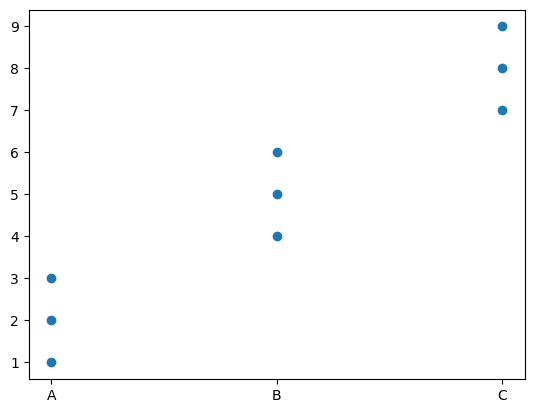

In [70]:
plt.scatter(x, y)

In [98]:
from tqdm import tqdm
import geopandas as gpd

regions = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

In [ ]:
from itertools import product

uppers = list()

carriers = [
    'offwind',
    'onwind',
    'solar',
    'industrial heat pump high temperature',
    'industrial heat pump medium temperature',
    'air heat pump',
    'ground heat pump',
    'CCGT',
    'OCGT',
    'biomass boiler',
]

wiggles = list(range(1000, 4250, 250))

for scen, wiggle in product(['fast', 'medium'], wiggles):

    uppers_df = pd.read_csv(
            path / template.format(scen, wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    
    for carrier in carriers:

        ss = uppers_df.loc[uppers_df.index.str.contains(carrier)]

        if ss.empty:
            continue

        ss = ss.groupby(ss.index.str[:5]).mean().reindex(regions.index).rename((scen, carrier, wiggle))

        uppers.append(ss)


100%|██████████| 13/13 [00:00<00:00, 63.91it/s]


In [111]:
pd.concat(uppers, axis=1)

fast                       \
             offwind         onwind solar   
                1000           1000  1000   
name                                        
AL0 0  -48885.305573       0.000000   0.0   
AT0 0            NaN  -74789.294488   0.0   
BA0 0   -8958.496194       0.000000   0.0   
BE0 0  -82711.274253  -71934.524311   0.0   
BG0 0 -311197.039048  -89703.896756   0.0   
CH0 0            NaN       0.000000   0.0   
CZ0 0            NaN -217798.010846   0.0   
DE0 0  -17681.844620   -1714.910056   0.0   
DE0 1            NaN  -50734.197399   0.0   
DE0 2  -56513.382448       0.000000   0.0   
DE0 3            NaN  -56442.373627   0.0   
DE0 4            NaN  -64073.077853   0.0   
DE0 5  -33974.547987   -2845.561619   0.0   
DK0 0  -10278.664077  -45268.673148   0.0   
DK1 0      -0.002078  -67808.403640   0.0   
EE0 0  -57600.668349  -56295.513045   0.0   
ES0 0  -14477.672417       0.000000   0.0   
ES6 0       0.000000  -53667.821615   0.0   
FI1 0   -3623.066758       0.000000   0.0   
FR0 0  -95425.389635  -67202.356982   0.0   
FR0 1  -75993.690551  -25460.794126   0.0   
FR0 2  -47196.658753  -15830.554198   0.0   
FR0 3  -87542.499805  -70103.592265   0.0   
FR0 4            NaN  -52768.285413   0.0   
FR5 0 -123473.074644 -164070.292470   0.0   
GB2 0  -22119.720551  -12820.181521   0.0   
GB2 1   -2433.439021  -10618.699900   0.0   
GB3 0  -15130.350775   -1779.750148   0.0   
GR0 0 -215250.643459 -103578.063081   0.0   
HR0 0 -108508.724479  -46062.584904   0.0   
HU0 0            NaN -131322.125281   0.0   
IE3 0  -14384.152671       0.000000   0.0   
IT0 0 -120280.712170  -54260.843216   0.0   
IT0 1 -135602.487046  -38971.415490   0.0   
IT4 0  -90320.756271 -100079.932269   0.0   
LT0 0  -50368.760990  -12691.591803   0.0   
LU0 0            NaN  -17309.437217   0.0   
LV0 0  -52860.586350  -28963.577180   0.0   
ME0 0   -2040.677158       0.000000   0.0   
MK0 0            NaN       0.000000   0.0   
NL0 0  -32012.370183  -39738.140935   0.0   
NO1 0   -3608.887466       0.000000   0.0   
PL0 0 -561181.839289 -303456.006951   0.0   
PT0 0  -29191.065469   -5548.002210   0.0   
RO0 0 -394434.774303  -95454.033495   0.0   
RS0 0            NaN  -55413.987263   0.0   
SE1 0   -3315.253501       0.000000   0.0   
SI0 0  -40380.212821       0.000000   0.0   
SK0 0            NaN -111538.948909   0.0   
XK0 0            NaN       0.000000   0.0   

                                             \
      industrial heat pump high temperature   
                                       1000   
name                                          
AL0 0                        -111664.953805   
AT0 0                        -310107.929711   
BA0 0                        -129102.085937   
BE0 0                        -161678.209730   
BG0 0                        -223245.613270   
CH0 0                        -210529.008816   
CZ0 0                        -295001.986019   
DE0 0                         -61918.703139   
DE0 1                        -178422.851424   
DE0 2                         -94621.353212   
DE0 3                        -277104.662180   
DE0 4                        -260557.771375   
DE0 5                         -82854.026813   
DK0 0                         -20713.663285   
DK1 0                         -18263.543373   
EE0 0                         -66486.154651   
ES0 0                        -153481.878428   
ES6 0                         -63710.616246   
FI1 0                         -28094.689243   
FR0 0                        -182264.114544   
FR0 1                        -233141.433480   
FR0 2                        -155124.051429   
FR0 3                        -142395.676723   
FR0 4                        -192908.290030   
FR5 0                        -103058.246808   
GB2 0                         -46400.330498   
GB2 1                         -53673.396663   
GB3 0                         -27314.187857   
GR0 0                        -208128.491402   
HR0 0                        -1461

In [102]:
regions

,geometry
name,
AL0 0,"MULTIPOLYGON (((19.44404 41.03374, 19.44275 41..."
AT0 0,"MULTIPOLYGON (((13.37242 46.57859, 13.36908 46..."
BA0 0,"MULTIPOLYGON (((18.00855 42.75464, 18.00809 42..."
BE0 0,"MULTIPOLYGON (((4.54113 49.96868, 4.53194 49.9..."
BG0 0,"POLYGON ((23.60586 41.37934, 23.5979 41.37818,..."
CH0 0,"POLYGON ((7.00603 46.00009, 7.00506 46.00066, ..."
CZ0 0,"POLYGON ((13.62304 48.93885, 13.63076 48.9471,..."
DE0 0,"MULTIPOLYGON (((8.52303 52.31667, 8.51273 52.3..."
DE0 1,"POLYGON ((11.09643 48.98604, 11.09567 48.98523..."


In [96]:
a = pd.DataFrame({'a': [1,2,3]})
a.reindex([0,1,2,3,4])

,a
0,1.0
1,2.0
2,3.0
3,NaN
4,NaN
